# 🚀 OOP Project — NLP Menu Application

**Congratulations on reaching the project!** 🎉 This is where we put **all of OOP together** to build a real, working application — an **NLP (Natural Language Processing) app** with a login system and three AI services.

> ✅ **Status of your original project:** it was almost complete! I finished the remaining flow and fixed a few bugs (details at the bottom). Most importantly, your original file had a **real API key written inside it** — I replaced it with a placeholder, because you should **never** put a real key in a file you share publicly.

---

## 🧠 What is NLP Cloud?

**NLP Cloud** is a website that gives us ready-made **NLP models** (AI models that understand human language). Instead of building AI from scratch, we just call their models. One common NLP task is **Named Entity Recognition (NER)** — finding specific "entities" (like names, places, or programming languages) inside a sentence.

## 🎯 The Plan — 3 NLP services

Once the user logs in, our app offers **three** NLP services:

| Option | Service | What it does |
|--------|---------|--------------|
| 1 | **Named Entity Recognition (NER)** | Find specific things in a paragraph (e.g. "find all programming languages"). Needs 2 inputs: the paragraph + what to search for. |
| 2 | **Language Detection** | Tell you which language a text is written in (Hindi, English, French...). |
| 3 | **Sentiment Analysis** | Tell you the *feeling* of a text (happy, angry, joy...). |

> 💡 We integrate only 3 models here, but you could add 10–15 different NLP services the same way. We build this **without a GUI** (graphical interface) for now — just a text menu.

## 🔄 The App Flow — a two-level menu

Our app has **two menus**:

```
┌─────────────────── FIRST MENU (before login) ───────────────────┐
│  1. Register     2. Login     3. Exit                             │
└──────────────────────────────────────────────────────────────────┘
        │                    │
   register a user      check email + password
        │                    │
        └──────────►  login successful
                             │
                             ▼
┌─────────────────── SECOND MENU (after login) ───────────────────┐
│  1. NER   2. Language Detection   3. Sentiment   4. Logout        │
└──────────────────────────────────────────────────────────────────┘
```

- **Register** → asks for name, email, password → saves the user → back to first menu.
- **Login** → checks email + password → if correct, opens the second menu.
- After any NLP service finishes → returns to the second menu.
- **Logout** → goes back to the first menu.

## Plan of Attack
### NLP Cloud is actually a API Provider.
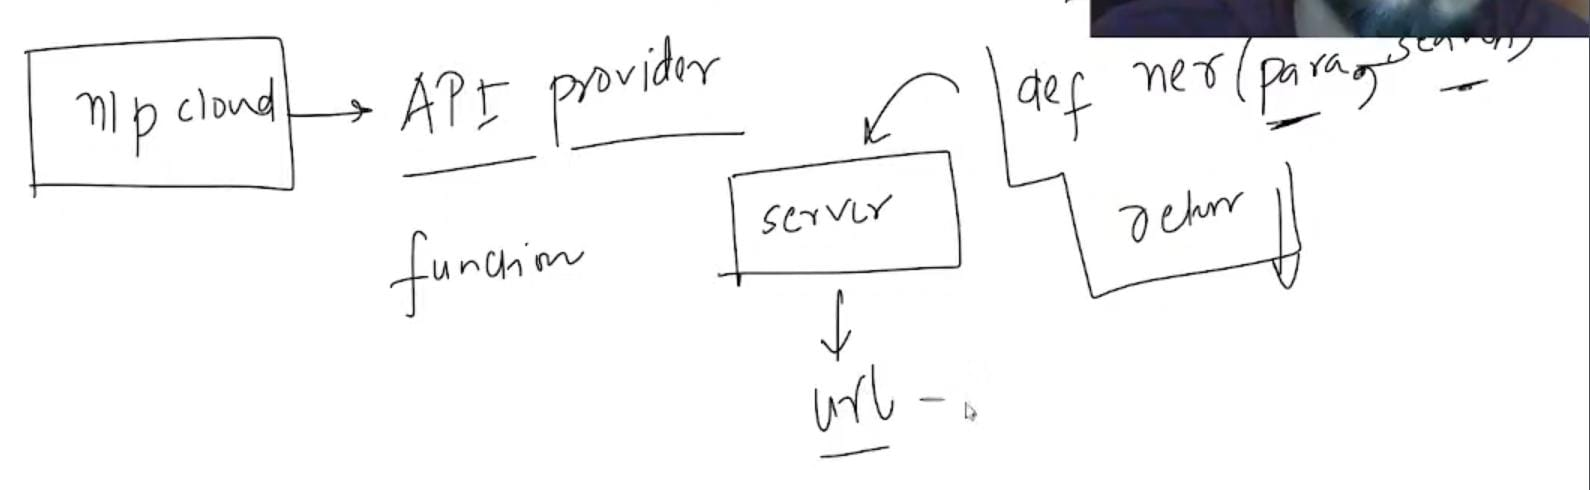
### API -> Application Programming Interface.Api ko hum 1 function k trah imagine kr sakte hai jo kissi website k server pe pada hua hai sp 1 function hai def ner jisko input 1 paragraph or dusra input me chahiye k hum kya search krna chahte hai,so agr hum iss functions ko dono input denge toh humko yeh return me bta dega k kon-kon sa words programming language hai in the given paragraph.So basically yeh 1 function hai jo server pe pada hua hai mtlb k uska 1 URL hai or iss URL ko koi bhi hit kr sakta hai mtlb sahi input de sakte hai or woh URL palat kr k kuch result return krega.

### So the plane of attack is k hum log python(OOP) use kr k 1 code likhenge jo uss URL pe hit krega with right set of parameters(sahi input dega) or woh URL se palat kr k result millega or ussi result ko display krayenge.Here we are not performing any ML,NLP Cloud wale ne sab kr rakha hai or woh log apne model ko API me convert kr dya hai or uss API ko bhi hamare jaise programmer access kr sakta hai sahi input deke results la sakta hai or software k uper display kr sakta hai.

### Till Now -> We find a website by name NLP Cloud and this website hame API's provide kr rha hai NLP k domain me jahan se humne 3 API's shortlist kiya apne project k lye

## ⚙️ Setup — install the NLP Cloud library

Run this once to install the `nlpcloud` package.

In [ ]:
!pip install nlpcloud

...


> 🔑 **You need a free API key from [nlpcloud.io](https://nlpcloud.io)** to use the NLP services. In the code below it appears as `"YOUR_API_KEY_HERE"` — replace it with your own key **only in your local copy**, and never commit the real key to GitHub.

## 🗄️ The "dictionary as a database" trick

Normally, a login/registration system stores users in a real **database**. We don't have one here, so we use a clever trick: a **Python dictionary** acts as our database.

- Each user is stored as `email → [name, password]`.
- We use the **email as the key**, because emails are unique (and dictionary keys must be unique).

Example of what our database looks like after two users register:
```python
{
    "azmishahab321@gmail.com": ["shahab", "1234"],
    "abc@gmail.com":           ["abc", "121"]
}
```

> ⚠️ Since this is just a dictionary in memory (RAM), all user data is **lost when the program closes**. A real database would keep it forever.

## 🏗️ How We Built It — Step by Step

We built the app **one method at a time**. Here is the plan (each step adds one piece to the `NLPApp` class):

| Step | What we added |
|------|---------------|
| 1 | The class + constructor (creates the private `__database` and shows the first menu) |
| 2 | `__first_menu()` — Register / Login / Exit options |
| 3 | `__register()` — ask for name, email, password |
| 4 | Save the new user into the `__database` dictionary |
| 5–6 | `__login()` — check the email and password |
| 7 | `__second_menu()` — the 4 options after login |
| 8 | Wire the second menu to the NLP methods |
| 9 | `__ner()`, `__language_detection()`, `__sentiment_analysis()` |

### 🔐 Notice the encapsulation!
Every method and the database use **`__`** (double underscore) to make them **private** — so no one using this class from outside can see or mess with the internal logic. This is exactly the **Encapsulation** you learned in Part 2. 🎯

Below is the **complete, finished, and fixed** class. Read the comments to see how each piece works.

In [ ]:
import nlpcloud

class NLPApp:
    def __init__(self):
        # __database is a dictionary that acts as our "database".
        # It is PRIVATE (__) so no outsider can touch our users' data (encapsulation).
        self.__database = {}
        self.__first_menu()          # show the first menu as soon as the app starts

    # ---------- FIRST MENU (before login) ----------
    def __first_menu(self):
        first_input = input("""
        Hi! How would you like to proceed?
        1. Not a member? Register
        2. Already a member? Login
        3. Just browsing? Exit
        """)
        if first_input == "1":
            self.__register()
        elif first_input == "2":
            self.__login()
        else:
            exit()

    # ---------- SECOND MENU (after login) ----------
    def __second_menu(self):
        second_input = input("""
        Login successful! What would you like to do?
        1. Named Entity Recognition (NER)
        2. Language Detection
        3. Sentiment Analysis
        4. Logout
        """)
        if second_input == "1":
            self.__ner()
        elif second_input == "2":
            self.__language_detection()     # FIX: added () so it actually runs
        elif second_input == "3":
            self.__sentiment_analysis()
        elif second_input == "4":
            print("Logged out.")
            self.__first_menu()             # FIX: logout returns to the first menu
        else:
            exit()

    # ---------- REGISTER ----------
    def __register(self):
        # These are plain local variables (no self.) because we only need them here.
        name = input("enter name: ")
        email = input("enter email: ")
        password = input("enter password: ")

        # Is this email already registered?
        if email in self.__database:
            print("email already exists")
        else:
            # store the new user: email -> [name, password]
            self.__database[email] = [name, password]
            print("registration successful. Now login.")
            print(self.__database)
            self.__first_menu()             # after registering, show the first menu again

    # ---------- LOGIN ----------
    def __login(self):
        email = input("enter email: ")
        password = input("enter password: ")

        if email in self.__database:
            # the password is the 2nd item in the list [name, password]
            if self.__database[email][1] == password:
                print("login successful")
                self.__second_menu()        # open the second menu on success
            else:
                print("wrong password, try again")
                self.__login()              # FIX: added () to actually retry
        else:
            print("this email is not registered")
            self.__first_menu()

    # ---------- NLP SERVICE 1: NER ----------
    def __ner(self):
        para = input("enter the paragraph: ")
        search_term = input("what would you like to search for: ")

        client = nlpcloud.Client("finetuned-llama-3-70b", "YOUR_API_KEY_HERE", gpu=True)
        response = client.entities(para, searched_entity=search_term)

        print(response)
        self.__second_menu()                # FIX: return to the menu after finishing

    # ---------- NLP SERVICE 2: Language Detection ----------
    def __language_detection(self):
        para = input("enter the text: ")

        client = nlpcloud.Client("python-langdetect", "YOUR_API_KEY_HERE", gpu=False)
        response = client.lang_detection(para)

        print(response)
        self.__second_menu()

    # ---------- NLP SERVICE 3: Sentiment Analysis ----------
    def __sentiment_analysis(self):
        para = input("enter the text: ")

        client = nlpcloud.Client("finetuned-llama-3-70b", "YOUR_API_KEY_HERE", gpu=True)
        response = client.sentiment(para)

        # FIX: find the label with the highest score (this logic was buggy/indented wrong)
        scores = [item["score"] for item in response["scored_labels"]]
        top_index = scores.index(max(scores))
        print("Sentiment:", response["scored_labels"][top_index]["label"])
        self.__second_menu()

## ▶️ Running the App

Just create an object — the constructor starts everything automatically (thanks to `self.__first_menu()`).

In [ ]:
obj = NLPApp()

### Example run (register + login)

Here's what a typical register-then-login session looks like. *(The NLP services themselves need a valid API key to respond.)*

```
Hi! How would you like to proceed?
1. Not a member? Register
2. Already a member? Login
3. Just browsing? Exit
> 1
enter name: shahab
enter email: shahab@gmail.com
enter password: 1234
registration successful. Now login.
{'shahab@gmail.com': ['shahab', '1234']}

Hi! How would you like to proceed?
> 2
enter email: shahab@gmail.com
enter password: 1234
login successful

Login successful! What would you like to do?
1. NER   2. Language Detection   3. Sentiment Analysis   4. Logout
> 2
enter text: bonjour tout le monde
(the model returns the detected language — e.g. French)
```

> 📝 The exact shape of each model's response depends on the NLP Cloud model you use — check the response with a `print()` and read it, rather than assuming a fixed format.

## 🛠️ What I Completed & Fixed

Your project was almost done — great work getting this far! Here is exactly what I changed to make it fully working:

| # | Issue in the original | Fix |
|---|-----------------------|-----|
| 1 | 🔐 **Real API key hardcoded** in the file | Replaced with `"YOUR_API_KEY_HERE"` (never commit real keys) |
| 2 | `self.__language_detection` had **no `()`** → never ran | Added `()` |
| 3 | Wrong-password retry `self.__login` had **no `()`** | Added `()` |
| 4 | **Logout** used `exit()` (quit the app) | Now returns to the first menu |
| 5 | NLP services **didn't return** to the menu after finishing | Added `self.__second_menu()` at the end of each |
| 6 | Sentiment analysis had an **indentation bug** (result found inside the loop) | Rewrote it to find the top label cleanly |
| 7 | Menu had small typos (`Detectioj`) and mixed Hindi | Cleaned into clear English |

## 🌟 Ideas to Take This Further

- Save the database to a **file** (using `json`) so users aren't lost when the app closes.
- **Hide the password** while typing using the `getpass` module.
- Add more NLP services (translation, summarization, question-answering).
- Build a **GUI** version later (with `tkinter` or a web framework) — the OOP structure makes this easy!

---

## 🎓 What This Project Taught You

| OOP Concept | Where you used it |
|-------------|-------------------|
| **Class & Object** | The whole `NLPApp` class; `obj = NLPApp()` |
| **Constructor** | `__init__` auto-starts the app |
| **Methods calling methods** | `self.__login()`, `self.__second_menu()`, etc. |
| **Encapsulation** | `__database` and all `__` private methods |
| **`self`** | How every method reaches the shared database |

**🏆 You built a complete, menu-driven AI application using pure OOP — this is a real, portfolio-worthy project. Amazing work!**